# HRRR Forecast to HEC-RAS: End-to-End Rain-on-Grid Execution

This notebook downloads one complete 18-hour High-Resolution Rapid Refresh (HRRR) forecast cycle, preserves the source timing in basin-average precipitation, writes hourly spatial precipitation grids to HEC-DSS, and runs the forcing through HEC-RAS 7.0.

The hydraulic demonstration uses the official **Bald Eagle Creek Multiple 2D Areas** example. Two otherwise identical plans are executed:

- **No-rain baseline** - isolates the hydraulic response from the retained non-precipitation boundary conditions.
- **Live HRRR forecast** - applies the spatially distributed forecast through HEC-RAS gridded meteorology.

The resulting HDF files are checked for precipitation timing and values, then compared using maximum depth, maximum water surface, wet-cell count, and a representative-cell depth hydrograph.

> **Scope and limitations:** This is an automation and hydraulic-evaluation demonstration, not an operational flood forecast. HRRR precipitation is live, but the example model retains a synthetic upstream flow hydrograph and the supplied 2.0-foot Sayers Dam gate opening because live flow and gate-operation forecasts are unavailable. The instructional model is coarse and is not calibrated for forecasting. Calculated hydraulic response requires professional review.

## Setup and Imports

In [1]:
# =============================================================================
# DEVELOPMENT MODE TOGGLE
# =============================================================================
# True  = use repository source; False = use the installed package.
USE_LOCAL_SOURCE = True

if USE_LOCAL_SOURCE:
    import sys
    from pathlib import Path

    repo_candidate = Path.cwd().parent if Path.cwd().name.lower() == "examples" else Path.cwd()
    local_path = str(repo_candidate)
    if local_path not in sys.path:
        sys.path.insert(0, local_path)
    print("LOCAL SOURCE MODE: Loading repository ras_commander")
else:
    print("PIP PACKAGE MODE: Loading installed ras-commander")

import warnings

with warnings.catch_warnings():
    warnings.filterwarnings(
        "ignore",
        message="IProgress not found.*",
        category=Warning,
        module=r"tqdm\.auto",
    )
    import ras_commander

source_label = "local source" if USE_LOCAL_SOURCE else "installed package"
print(f"Loaded ras-commander {ras_commander.__version__} from {source_label}")

LOCAL SOURCE MODE: Loading repository ras_commander


Loaded ras-commander 0.98.2 from local source


In [2]:
from datetime import datetime, timedelta, timezone
from importlib.metadata import version as package_version
import logging
from pathlib import Path
import shutil
import warnings

import matplotlib.pyplot as plt
import geopandas as gpd
import numpy as np
import pandas as pd
from shapely.geometry import box

from qpkit import BoundingBox, HRRRGridOptions, HRRRRequest, QPKit
from ras_commander import (
    HdfBndry,
    HdfInfiltration,
    HdfMesh,
    HdfProject,
    HdfResultsMesh,
    HdfResultsPlan,
    HdfStruc,
    RasCmdr,
    RasDss,
    RasExamples,
    RasPlan,
    RasUnsteady,
    get_ras_exe,
    init_ras_project,
)
from ras_commander.precip import PrecipHrrr

for logger_name in (
    "httpx",
    "pydsstools",
    "pydsstools.heclib.logging",
    "qpkit",
    "qpkit.services.dss.hrrr",
    "qpkit.services.dss._helpers",
    "rasterio",
    "rasterio._env",
    "rasterio._err",
    "ras_commander.precip.PrecipHrrr",
    "ras_commander.RasUnsteady",
):
    logging.getLogger(logger_name).setLevel(logging.WARNING)

QPKIT_VERSION = package_version("qpkit")
if QPKIT_VERSION != "0.1.0":
    raise RuntimeError(f"This workflow requires qpkit 0.1.0; found {QPKIT_VERSION}")

repo_root = Path.cwd().parent if Path.cwd().name.lower() == "examples" else Path.cwd()
run_stamp = datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%SZ")
run_root = repo_root / "working" / "example_916_hrrr_ras" / run_stamp
run_root.mkdir(parents=True, exist_ok=False)

RAS_VERSION = "7.0"
FORECAST_HOURS = 18
COMPLETE_CYCLE_LAG_HOURS = 20
PRECIPITATION_BUFFER_PERCENT = 25.0
COMPUTATION_INTERVAL = "10SEC"
MAX_WSEL_ERROR_FT = 0.1
MESH_NAME = "BaldEagleCr"
TEMPLATE_PLAN = "06"
TEMPLATE_UNSTEADY = "03"
TEMPLATE_GEOMETRY = "09"
ras_exe = get_ras_exe(RAS_VERSION)

print(f"qpkit {QPKIT_VERSION}")
print(f"HEC-RAS {RAS_VERSION} is available")
print(f"Working folder: {run_root}")

2026-07-11 23:20:14 - pydsstools.heclib.logging - INFO - DssLogger(GLOBAL, level=TERSE): level set — method=GLOBAL, level=TERSE.


qpkit 0.1.0
HEC-RAS 7.0 is available
Working folder: C:\Users\bill\.config\superpowers\worktrees\ras-commander\codex-hrrr-basin-time\working\example_916_hrrr_ras\20260712T032014Z


## Workflow Contract

This notebook demonstrates and verifies the complete chain:

1. Select one sufficiently mature HRRR cycle.
2. Download the 18-hour subhourly precipitation product with `PrecipHrrr`.
3. Preserve HRRR `valid_time` and `forecast_lead_hours` in basin-average results.
4. Write the same cycle as 18 hourly incremental DSS grids in SHG.
5. Inspect the HEC-RAS model, geometry, boundary conditions, and retained assumptions.
6. Clone baseline and forecast plans without modifying the official example.
7. Execute both plans through `RasCmdr.compute_plan()`.
8. Verify applied precipitation from the plan HDF files.
9. Compare hydraulic depth and water-surface response.

NOMADS availability is live. Missing data, failed DSS records, HEC-RAS compute failures, and HDF validation failures intentionally stop the notebook rather than presenting partial results.

## Select One Complete HRRR Cycle

HRRR runs hourly, but the newest published cycle normally does not yet contain its complete 18-hour horizon. The notebook finds the latest published cycle and steps back 20 hours: 18 hours for forecast maturity plus a small publication margin. Both the basin-average analysis and HEC-RAS DSS forcing use this exact cycle.

In [3]:
info = PrecipHrrr.get_info()
with QPKit(logger=logging.getLogger("qpkit")) as kit:
    latest_date, latest_hour = kit.hrrr.find_latest_cycle()

latest_cycle = datetime(
    latest_date.year,
    latest_date.month,
    latest_date.day,
    latest_hour,
    tzinfo=timezone.utc,
)
selected_cycle = latest_cycle - timedelta(hours=COMPLETE_CYCLE_LAG_HOURS)
simulation_start = selected_cycle.replace(tzinfo=None)
simulation_end = simulation_start + timedelta(hours=FORECAST_HOURS)

available = PrecipHrrr.check_availability(
    date=selected_cycle.strftime("%Y-%m-%d"),
    cycle=selected_cycle.hour,
)
if not available:
    raise RuntimeError(f"Selected HRRR cycle is unavailable: {selected_cycle:%Y-%m-%d %H}Z")

cycle_summary = pd.DataFrame(
    [
        {
            "data_source": info["provider"],
            "latest_published_cycle_utc": latest_cycle,
            "selected_complete_cycle_utc": selected_cycle,
            "forecast_end_utc": selected_cycle + timedelta(hours=FORECAST_HOURS),
            "forecast_horizon_hours": FORECAST_HOURS,
        }
    ]
)
display(cycle_summary)

,data_source,latest_published_cycle_utc,selected_complete_cycle_utc,forecast_end_utc,forecast_horizon_hours
0,NOAA / NCEP,2026-07-12 02:00:00+00:00,2026-07-11 06:00:00+00:00,2026-07-12 00:00:00+00:00,18


## Inspect the HEC-RAS Demonstration Model

The official HEC-RAS 7.0 archive is extracted into the ignored `working/` folder. Plan `p06` is the established gridded-precipitation and infiltration configuration using unsteady file `u03` and geometry `g09`.

The non-precipitation boundary conditions use relative schedules, so shifting the plan to the selected HRRR window does not truncate them. They are retained identically in the baseline and forecast plans:

- A synthetic hourly upstream flow hydrograph.
- Two downstream normal-depth boundaries with slope 0.0003.
- Sayers Dam Gate #1 fixed at the example's 2.0-foot opening for all 100 six-hour values.

These retained schedules are scenario assumptions. They are not live operational forecasts.

2026-07-11 23:20:17 - ras_commander.RasExamples - INFO - Successfully extracted project 'BaldEagleCrkMulti2D' to BaldEagleCrkMulti2D_hrrr_forecast


,value
HEC-RAS version,7.0
template plan,p06 - Gridded Precip - Infiltration
unsteady flow,u03
geometry,g09
mesh,BaldEagleCr
computational mesh cells,18066
result/center records,19597
nominal mesh spacing,250 x 250 ft
computation interval,20SEC
equation,2D diffusion wave (supplied example)


Preprocessed infiltration statistics:


,mesh_name,n_cells,min_val,max_val,mean_val,median_val,std_val,variable
0,BaldEagleCr,18066,36.0,100.0,73.645,73.0,14.803,Curve Number


Boundary conditions retained in both plans:


,area_2d,bc_line_name,bc_type,hydrograph_type,Interval,hydrograph_num_values,Use DSS,Fixed Start Date/Time
47,BaldEagleCr,DSNormalDepth,Normal Depth,NaN,NaN,0,NaN,NaN
48,BaldEagleCr,Upstream Inflow,Flow Hydrograph,Flow Hydrograph,1HOUR,1000,False,","
49,BaldEagleCr,DS2NormalD,Normal Depth,NaN,NaN,0,NaN,NaN
50,,,Gate Opening,NaN,NaN,0,NaN,NaN


Sayers Dam Gate #1: 100 values at 6HOUR, all 2.0 ft


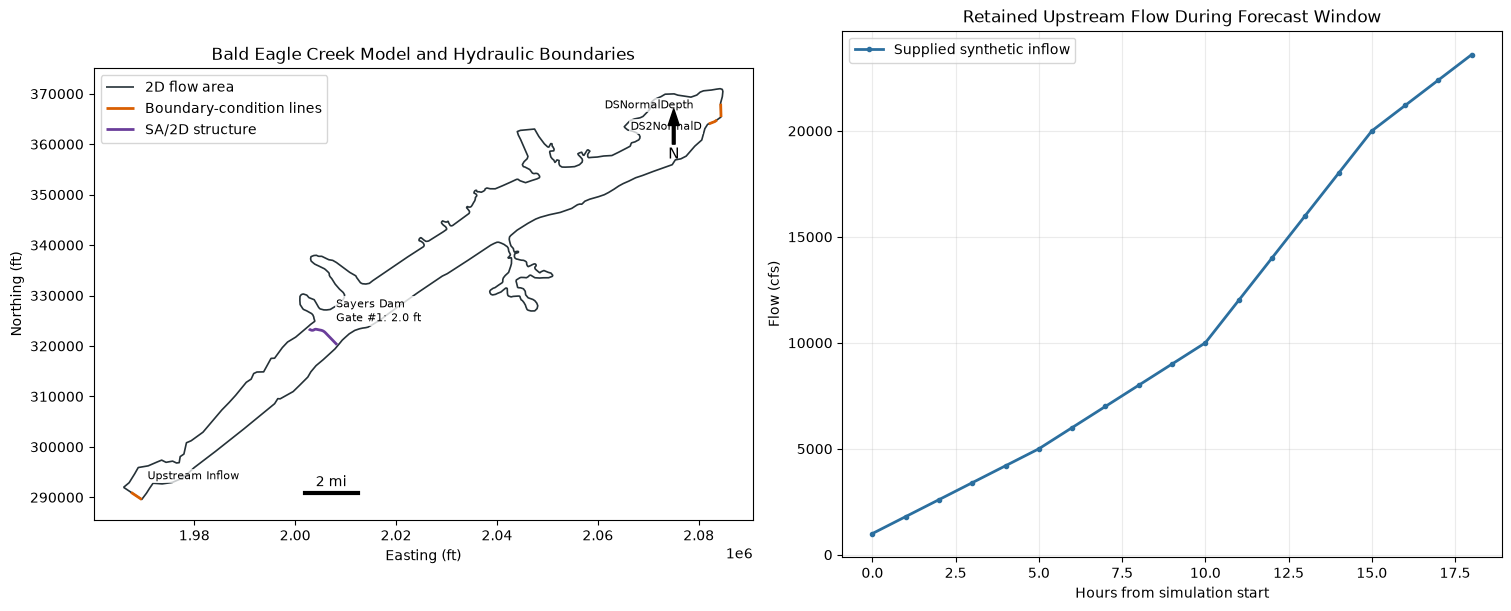

Extracted project for GUI review: C:\Users\bill\.config\superpowers\worktrees\ras-commander\codex-hrrr-basin-time\working\example_916_hrrr_ras\20260712T032014Z\model\BaldEagleCrkMulti2D_hrrr_forecast


In [4]:
project_path = RasExamples.extract_project(
    "BaldEagleCrkMulti2D",
    output_path=run_root / "model",
    suffix="hrrr_forecast",
)
ras = init_ras_project(
    project_path,
    ras_version=RAS_VERSION,
    load_results_summary=False,
    hide_intro=True,
)

template_plan_row = ras.plan_df.loc[
    ras.plan_df["plan_number"].astype(str).str.zfill(2) == TEMPLATE_PLAN
].iloc[0]
if str(template_plan_row["unsteady_number"]).zfill(2) != TEMPLATE_UNSTEADY:
    raise RuntimeError("Template plan does not reference expected unsteady file u03")
if str(template_plan_row["geometry_number"]).zfill(2) != TEMPLATE_GEOMETRY:
    raise RuntimeError("Template plan does not reference expected geometry g09")

geometry_hdf = ras.project_folder / f"{ras.project_name}.g{TEMPLATE_GEOMETRY}.hdf"
template_unsteady_path = ras.project_folder / f"{ras.project_name}.u{TEMPLATE_UNSTEADY}"
project_bounds = tuple(
    float(value)
    for value in HdfProject.get_project_bounds_latlon(
        geometry_hdf,
        buffer_percent=0.0,
    )
)
BOUNDS = tuple(
    float(value)
    for value in HdfProject.get_project_bounds_latlon(
        geometry_hdf,
        buffer_percent=PRECIPITATION_BUFFER_PERCENT,
    )
)
mesh_areas = HdfMesh.get_mesh_areas(geometry_hdf)
mesh_attributes = HdfMesh.get_mesh_area_attributes(geometry_hdf)
mesh_cell_count = int(np.asarray(mesh_attributes.loc["Cell Count", "Value"]).reshape(-1)[0])
nominal_spacing_x_ft = float(
    np.asarray(mesh_attributes.loc["Spacing dx", "Value"]).reshape(-1)[0]
)
nominal_spacing_y_ft = float(
    np.asarray(mesh_attributes.loc["Spacing dy", "Value"]).reshape(-1)[0]
)
mesh_cell_points = HdfMesh.get_mesh_cell_points(geometry_hdf)
mesh_cell_faces = HdfMesh.get_mesh_cell_faces(geometry_hdf)
bc_lines = HdfBndry.get_bc_lines(geometry_hdf)
structures = HdfStruc.get_structures(geometry_hdf)
infiltration_stats = HdfInfiltration.get_preprocessed_infiltration_stats(
    geometry_hdf,
    mesh_name=MESH_NAME,
    variable="Curve Number",
)
inline_boundaries = RasUnsteady.get_inline_hydrograph_boundaries(
    template_unsteady_path,
    ras_object=ras,
)
gate = RasUnsteady.get_gate_openings(TEMPLATE_UNSTEADY, ras_object=ras)

if gate["gate_name"] != "Gate #1" or gate["count"] != 100:
    raise RuntimeError(f"Unexpected Sayers Dam gate schedule: {gate}")
if not np.allclose(gate["values"], 2.0):
    raise RuntimeError("The supplied Sayers Dam gate schedule is not uniformly 2.0 ft")

boundary_columns = [
    column
    for column in [
        "area_2d",
        "bc_line_name",
        "bc_type",
        "hydrograph_type",
        "Interval",
        "hydrograph_num_values",
        "Use DSS",
        "Fixed Start Date/Time",
    ]
    if column in ras.boundaries_df.columns
]
boundary_context = ras.boundaries_df.loc[
    ras.boundaries_df["unsteady_number"].astype(str).str.zfill(2) == TEMPLATE_UNSTEADY,
    boundary_columns,
].copy()

model_summary = pd.DataFrame(
    [
        {
            "HEC-RAS version": RAS_VERSION,
            "template plan": f"p{TEMPLATE_PLAN} - {template_plan_row['Plan Title']}",
            "unsteady flow": f"u{TEMPLATE_UNSTEADY}",
            "geometry": f"g{TEMPLATE_GEOMETRY}",
            "mesh": MESH_NAME,
            "computational mesh cells": mesh_cell_count,
            "result/center records": len(mesh_cell_points),
            "nominal mesh spacing": f"{nominal_spacing_x_ft:g} x {nominal_spacing_y_ft:g} ft",
            "computation interval": template_plan_row["Computation Interval"],
            "equation": "2D diffusion wave (supplied example)",
            "terrain": Path(ras.rasmap_df.iloc[0]["terrain_hdf_path"][0]).name,
            "infiltration": Path(ras.rasmap_df.iloc[0]["infiltration_hdf_path"][0]).name,
            "model WGS84 bounds": project_bounds,
            "precipitation query bounds": BOUNDS,
        }
    ]
)
display(model_summary.T.rename(columns={0: "value"}))
print("Preprocessed infiltration statistics:")
display(infiltration_stats.round(3))
print("Boundary conditions retained in both plans:")
display(boundary_context)
print(
    f"Sayers Dam {gate['gate_name']}: {gate['count']} values at {gate['interval']}, "
    f"all {gate['values'][0]:.1f} ft"
)

flow_rows = inline_boundaries.loc[inline_boundaries["bc_type"] == "Flow Hydrograph"]
if flow_rows.empty:
    raise RuntimeError("Expected an inline upstream flow hydrograph in u03")
flow_values = np.asarray(flow_rows.iloc[0]["values"], dtype=float)
flow_hours = np.arange(len(flow_values), dtype=float)

fig, (ax_model, ax_flow) = plt.subplots(1, 2, figsize=(15, 6), constrained_layout=True)
mesh_areas.boundary.plot(ax=ax_model, color="#263238", linewidth=1.2, label="2D flow area")
if not bc_lines.empty:
    bc_lines.plot(ax=ax_model, color="#d95f02", linewidth=2.0, label="Boundary-condition lines")
    name_column = "Name" if "Name" in bc_lines.columns else None
    if name_column:
        for _, row in bc_lines.iterrows():
            point = row.geometry.interpolate(0.5, normalized=True)
            label = str(row[name_column])
            offsets = {
                "Upstream Inflow": (8, 12),
                "DSNormalDepth": (-78, 10),
                "DS2NormalD": (-65, -14),
            }
            ax_model.annotate(
                label,
                (point.x, point.y),
                xytext=offsets.get(label, (6, 6)),
                textcoords="offset points",
                fontsize=8,
                bbox=dict(facecolor="white", edgecolor="none", alpha=0.75, pad=1),
            )
if not structures.empty:
    structures.plot(ax=ax_model, color="#6a3d9a", linewidth=2.0, label="SA/2D structure")
    for _, row in structures.iterrows():
        structure_name = str(row.get("Connection") or row.get("Groupname") or "Structure")
        point = row.geometry.interpolate(0.5, normalized=True)
        ax_model.annotate(
            f"{structure_name}\nGate #1: 2.0 ft",
            (point.x, point.y),
            xytext=(8, 8),
            textcoords="offset points",
            fontsize=8,
            bbox=dict(facecolor="white", edgecolor="none", alpha=0.8, pad=1),
        )
ax_model.set_title("Bald Eagle Creek Model and Hydraulic Boundaries")
ax_model.set_xlabel("Easting (ft)")
ax_model.set_ylabel("Northing (ft)")
ax_model.set_aspect("equal")
ax_model.legend(loc="best")
ax_model.annotate(
    "N",
    xy=(0.88, 0.91),
    xytext=(0.88, 0.80),
    xycoords="axes fraction",
    arrowprops=dict(facecolor="black", width=2, headwidth=8),
    ha="center",
    fontsize=11,
)
xmin, xmax = ax_model.get_xlim()
ymin, ymax = ax_model.get_ylim()
scale_ft = 2 * 5280
scale_x = xmin + 0.32 * (xmax - xmin)
scale_y = ymin + 0.06 * (ymax - ymin)
ax_model.plot([scale_x, scale_x + scale_ft], [scale_y, scale_y], color="black", linewidth=3)
ax_model.text(scale_x + scale_ft / 2, scale_y + 0.015 * (ymax - ymin), "2 mi", ha="center")

display_hours = min(FORECAST_HOURS, len(flow_values) - 1)
ax_flow.plot(
    flow_hours[: display_hours + 1],
    flow_values[: display_hours + 1],
    color="#2b6f9f",
    linewidth=2,
    marker="o",
    markersize=3,
    label="Supplied synthetic inflow",
)
ax_flow.set(
    title="Retained Upstream Flow During Forecast Window",
    xlabel="Hours from simulation start",
    ylabel="Flow (cfs)",
)
ax_flow.grid(alpha=0.25)
ax_flow.legend()
plt.show()

print(f"Extracted project for GUI review: {ras.project_folder}")

## Download and Analyze Source-Timed Precipitation

`PrecipHrrr.download_forecast()` retrieves forecast hours 1 through 18 from the selected `wrfsubhf` cycle. Each file contains four 15-minute accumulated-precipitation records. The API retains those source timestamps rather than treating the records as hourly values.

The rectangular geometry below is the HEC-RAS model extent with a 25% buffer, derived through `HdfProject`. It is an analysis and forcing-coverage window, not a delineated watershed. A production basin average should use the engineering watershed polygon.

In [5]:
cycle_cache_root = (
    repo_root
    / "working"
    / "example_916_hrrr_cache"
    / selected_cycle.strftime("%Y%m%dT%HZ")
)
subhourly_grib_dir = cycle_cache_root / "subhourly_grib"
grib_files = PrecipHrrr.download_forecast(
    output_dir=subhourly_grib_dir,
    date=selected_cycle.strftime("%Y-%m-%d"),
    cycle=selected_cycle.hour,
    hours=FORECAST_HOURS,
    overwrite=False,
)
if len(grib_files) != FORECAST_HOURS:
    raise RuntimeError(f"Expected {FORECAST_HOURS} HRRR files; received {len(grib_files)}")
if any(not path.is_file() or path.stat().st_size == 0 for path in grib_files):
    raise RuntimeError("One or more HRRR GRIB2 files are missing or empty")

total_gb = sum(path.stat().st_size for path in grib_files) / 1024**3
print(f"Downloaded {len(grib_files)} source-timed GRIB2 files ({total_gb:.2f} GB)")
print(f"First file: {grib_files[0].name}")
print(f"Last file:  {grib_files[-1].name}")

Downloaded 18 source-timed GRIB2 files (3.54 GB)
First file: hrrr.t06z.wrfsubhf01.grib2
Last file:  hrrr.t06z.wrfsubhf18.grib2


,forecast_hour,valid_time,forecast_lead_hours,precip_inches,cumulative_inches
0,1,2026-07-11 06:15 UTC,0.25,0.00000,0.000
1,2,2026-07-11 06:30 UTC,0.50,0.00000,0.000
2,3,2026-07-11 06:45 UTC,0.75,0.00000,0.000
3,4,2026-07-11 07:00 UTC,1.00,0.00000,0.000
4,5,2026-07-11 07:15 UTC,1.25,0.00000,0.000
5,6,2026-07-11 07:30 UTC,1.50,0.00000,0.000
66,67,2026-07-11 22:45 UTC,16.75,0.00000,0.066
67,68,2026-07-11 23:00 UTC,17.00,0.00000,0.066
68,69,2026-07-11 23:15 UTC,17.25,0.00000,0.066
69,70,2026-07-11 23:30 UTC,17.50,0.00000,0.066


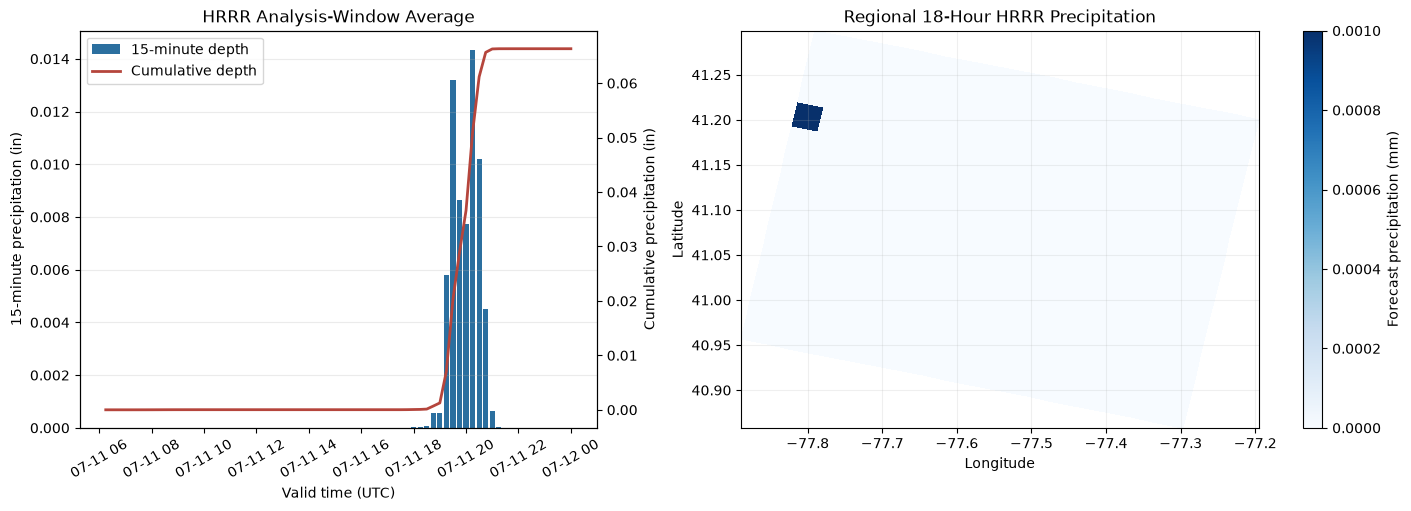

Source records: 72 at 15-minute cadence
Valid-time coverage: 2026-07-11 06:15:00 through 2026-07-12 00:00:00
Analysis-window total: 0.066 inches


In [6]:
precip_ds = PrecipHrrr.extract_precipitation(grib_files=grib_files, bounds=BOUNDS)
valid_times = pd.DatetimeIndex(pd.to_datetime(precip_ds["valid_time"].values))
cadence = valid_times.to_series().diff().dropna().unique()
if len(cadence) != 1 or cadence[0] != pd.Timedelta(minutes=15):
    raise RuntimeError(f"Expected uniform 15-minute HRRR cadence; found {cadence}")

cycle_values = pd.DatetimeIndex(pd.to_datetime(np.asarray(precip_ds["time"].values).reshape(-1)))
if len(cycle_values.unique()) != 1:
    raise RuntimeError("Extracted HRRR records contain multiple forecast cycles")
dataset_cycle = pd.Timestamp(cycle_values[0]).tz_localize("UTC")
if dataset_cycle != selected_cycle:
    raise RuntimeError(f"Dataset cycle {dataset_cycle} does not match selected cycle {selected_cycle}")

analysis_geometry = box(*BOUNDS)
avg_precip = PrecipHrrr.get_basin_average(grib_files=grib_files, geometry=analysis_geometry)
api_valid_times = pd.DatetimeIndex(pd.to_datetime(avg_precip["valid_time"]))
if not api_valid_times.equals(valid_times):
    raise RuntimeError("Basin-average valid times do not match the extracted HRRR dataset")

expected_leads = pd.to_timedelta(precip_ds["step"].values).total_seconds() / 3600.0
if not np.allclose(avg_precip["forecast_lead_hours"], expected_leads):
    raise RuntimeError("Basin-average forecast leads do not match HRRR step metadata")

preview = pd.concat([avg_precip.head(6), avg_precip.tail(6)]).drop_duplicates()
display(
    preview[
        [
            "forecast_hour",
            "valid_time",
            "forecast_lead_hours",
            "precip_inches",
            "cumulative_inches",
        ]
    ].style.format(
        {
            "valid_time": lambda value: pd.Timestamp(value).strftime("%Y-%m-%d %H:%M UTC"),
            "forecast_lead_hours": "{:.2f}",
            "precip_inches": "{:.5f}",
            "cumulative_inches": "{:.3f}",
        }
    )
)

fig, (ax_hyetograph, ax_map) = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)
ax_hyetograph.bar(
    avg_precip["valid_time"],
    avg_precip["precip_inches"],
    width=pd.Timedelta(minutes=12),
    color="#2b6f9f",
    label="15-minute depth",
)
ax_cumulative = ax_hyetograph.twinx()
ax_cumulative.plot(
    avg_precip["valid_time"],
    avg_precip["cumulative_inches"],
    color="#b5453c",
    linewidth=2,
    label="Cumulative depth",
)
ax_hyetograph.set(
    title="HRRR Analysis-Window Average",
    xlabel="Valid time (UTC)",
    ylabel="15-minute precipitation (in)",
)
ax_cumulative.set_ylabel("Cumulative precipitation (in)")
handles_1, labels_1 = ax_hyetograph.get_legend_handles_labels()
handles_2, labels_2 = ax_cumulative.get_legend_handles_labels()
ax_hyetograph.legend(handles_1 + handles_2, labels_1 + labels_2, loc="upper left")
ax_hyetograph.tick_params(axis="x", rotation=30)
ax_hyetograph.grid(axis="y", alpha=0.25)

total_grid = precip_ds["tp"].sum(dim="step", skipna=True)
plot_longitude = ((precip_ds["longitude"] + 180.0) % 360.0) - 180.0
image = ax_map.pcolormesh(
    plot_longitude,
    precip_ds["latitude"],
    total_grid,
    shading="auto",
    cmap="Blues",
)
ax_map.set(
    title="Regional 18-Hour HRRR Precipitation",
    xlabel="Longitude",
    ylabel="Latitude",
)
ax_map.grid(alpha=0.2)
fig.colorbar(image, ax=ax_map, label="Forecast precipitation (mm)")
plt.show()

print(f"Source records: {len(avg_precip)} at 15-minute cadence")
print(f"Valid-time coverage: {valid_times[0]} through {valid_times[-1]}")
print(f"Analysis-window total: {avg_precip['cumulative_inches'].iloc[-1]:.3f} inches")

## Write the Selected Forecast Cycle to HEC-DSS

qpkit downloads the regional HRRR surface product for the same selected cycle and differences its running APCP totals into 18 one-hour `PER-CUM` grids. The grids are reprojected to Standard Hydrologic Grid (SHG) coordinates for HEC-RAS interpolation and stored inside the extracted project so the precipitation reference is portable.

The source-timing section uses the subhourly HRRR product, while the DSS forcing uses the hourly surface product. They share the same forecast cycle and 18-hour window but should not be expected to have identical spatial averages because they are different HRRR products and temporal aggregations.

,pathname,start_time,end_time,minimum_mm,mean_mm,maximum_mm,rows,columns,cell_size_m
0,/SHG/BALD_EAGLE_CREEK/PRECIPITATION/11JUL2026:...,2026-07-11 06:00:00,2026-07-11 07:00:00,0.0,0.000036,0.002,14,18,3000.0
1,/SHG/BALD_EAGLE_CREEK/PRECIPITATION/11JUL2026:...,2026-07-11 07:00:00,2026-07-11 08:00:00,0.0,0.000000,0.000,14,18,3000.0
2,/SHG/BALD_EAGLE_CREEK/PRECIPITATION/11JUL2026:...,2026-07-11 08:00:00,2026-07-11 09:00:00,0.0,0.000000,0.000,14,18,3000.0
15,/SHG/BALD_EAGLE_CREEK/PRECIPITATION/11JUL2026:...,2026-07-11 21:00:00,2026-07-11 22:00:00,0.0,0.000090,0.010,14,18,3000.0
16,/SHG/BALD_EAGLE_CREEK/PRECIPITATION/11JUL2026:...,2026-07-11 22:00:00,2026-07-11 23:00:00,0.0,0.000000,0.000,14,18,3000.0
17,/SHG/BALD_EAGLE_CREEK/PRECIPITATION/11JUL2026:...,2026-07-11 23:00:00,2026-07-12 00:00:00,0.0,0.000000,0.000,14,18,3000.0


DSS spatial-coverage audit:


,feature,covered,total,coverage_percent
0,result/cell centers,19597,19597,100.0
1,mesh faces,37594,37594,100.0


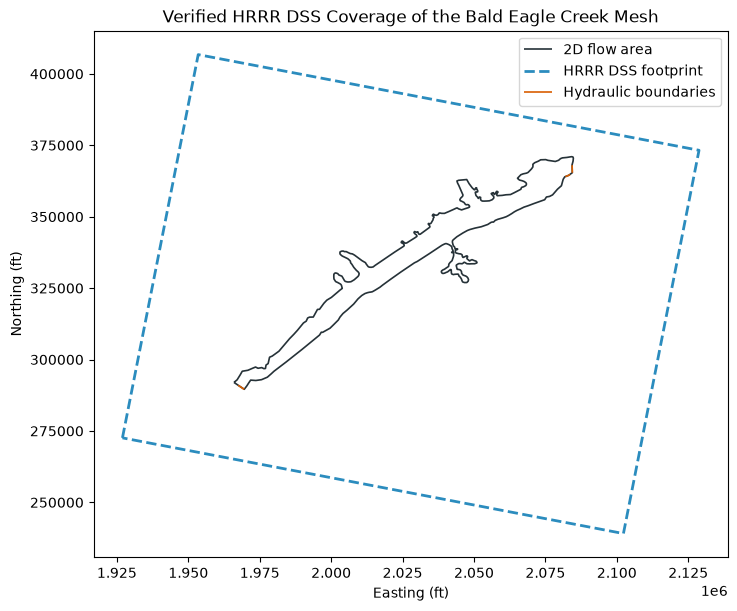

DSS records: 18 hourly SHG grids
DSS coverage: 2026-07-11 06:00:00 through 2026-07-12 00:00:00
DSS file: C:\Users\bill\.config\superpowers\worktrees\ras-commander\codex-hrrr-basin-time\working\example_916_hrrr_ras\20260712T032014Z\model\BaldEagleCrkMulti2D_hrrr_forecast\Precipitation\hrrr_forecast\hrrr_bald_eagle_precip.dss


In [7]:
precipitation_dir = ras.project_folder / "Precipitation" / "hrrr_forecast"
precipitation_dir.mkdir(parents=True, exist_ok=True)
qpkit_grib_dir = cycle_cache_root / "surface_grib"
qpkit_grib_dir.mkdir(parents=True, exist_ok=True)
hrrr_dss_file = precipitation_dir / "hrrr_bald_eagle_precip.dss"

hrrr_request = HRRRRequest(
    precip_type="APCP",
    cycle_date=selected_cycle.date(),
    cycle_hour=selected_cycle.hour,
    forecast_hours=(FORECAST_HOURS,),
    bbox=BoundingBox(
        left_lon=BOUNDS[0],
        right_lon=BOUNDS[2],
        top_lat=BOUNDS[3],
        bottom_lat=BOUNDS[1],
    ),
)
hrrr_grid_options = HRRRGridOptions.for_apcp(
    part_a="SHG",
    part_b="BALD_EAGLE_CREEK",
    part_c="PRECIPITATION",
    part_f="HRRR-APCP-1H",
    cell_size=3000.0,
    overwrite=False,
)

with QPKit(logger=logging.getLogger("qpkit")) as kit:
    with warnings.catch_warnings():
        warnings.filterwarnings(
            "ignore",
            message="You will likely lose important projection information.*",
            category=UserWarning,
            module=r"pyproj\.crs\.crs",
        )
        hrrr_result = kit.download_to_dss(
            hrrr_request,
            qpkit_grib_dir,
            hrrr_dss_file,
            grid_options=hrrr_grid_options,
            dss_version=7,
            interval=1,
            force=True,
        )

if hrrr_result.download.failed or hrrr_result.dss.failed:
    raise RuntimeError(
        f"HRRR-to-DSS failure: downloads={hrrr_result.download.failed}, "
        f"DSS={hrrr_result.dss.failed}"
    )
if len(hrrr_result.download.all_files) != FORECAST_HOURS + 1:
    raise RuntimeError("Expected f00 through f18 for hourly differencing")
if len(hrrr_result.dss.written) != FORECAST_HOURS:
    raise RuntimeError(f"Expected {FORECAST_HOURS} DSS grids; wrote {len(hrrr_result.dss.written)}")

hrrr_catalog = RasDss.get_catalog(hrrr_dss_file)
if len(hrrr_catalog) != FORECAST_HOURS:
    raise RuntimeError(f"Expected {FORECAST_HOURS} catalog records; found {len(hrrr_catalog)}")

grid_rows = []
for pathname in hrrr_catalog["pathname"].astype(str):
    grid = RasDss.read_grid(hrrr_dss_file, pathname)
    values = np.asarray(grid["data"], dtype=float)
    finite = values[np.isfinite(values)]
    if not finite.size or np.any(finite < -1e-9):
        raise RuntimeError(f"Invalid DSS precipitation values: {pathname}")
    if grid["units"].upper() != "MM" or grid["data_type"].upper() != "PER-CUM":
        raise RuntimeError(f"Unexpected DSS units/type: {grid['units']}, {grid['data_type']}")
    if grid["grid_type"].lower() != "albers" or "North_American_1983" not in grid["crs"]:
        raise RuntimeError("DSS grid is not in the expected SHG Albers coordinate system")
    grid_rows.append(
        {
            "pathname": pathname,
            "start_time": pd.Timestamp(grid["start_time"]),
            "end_time": pd.Timestamp(grid["end_time"]),
            "minimum_mm": float(finite.min()),
            "mean_mm": float(finite.mean()),
            "maximum_mm": float(finite.max()),
            "rows": grid["shape"][0],
            "columns": grid["shape"][1],
            "cell_size_m": float(grid["cell_size"]),
        }
    )

dss_audit = pd.DataFrame(grid_rows).sort_values("start_time").reset_index(drop=True)
expected_starts = pd.date_range(simulation_start, periods=FORECAST_HOURS, freq="h")
expected_ends = expected_starts + pd.Timedelta(hours=1)
if dss_audit["start_time"].tolist() != expected_starts.tolist():
    raise RuntimeError("DSS start times do not match the selected HRRR cycle")
if dss_audit["end_time"].tolist() != expected_ends.tolist():
    raise RuntimeError("DSS end times do not match the 18-hour simulation window")
if not np.allclose(dss_audit["cell_size_m"], 3000.0):
    raise RuntimeError("Unexpected DSS grid cell size")

first_dss_pathname = dss_audit.iloc[0]["pathname"]
first_grid = RasDss.read_grid(hrrr_dss_file, first_dss_pathname)
grid_metadata = first_grid["metadata"]
origin_x, origin_y = grid_metadata["origin"]
grid_rows_count, grid_columns_count = first_grid["shape"]
grid_cell_size = float(first_grid["cell_size"])
dss_footprint_shg = gpd.GeoDataFrame(
    {"source": ["HRRR DSS footprint"]},
    geometry=[
        box(
            origin_x,
            origin_y,
            origin_x + grid_columns_count * grid_cell_size,
            origin_y + grid_rows_count * grid_cell_size,
        )
    ],
    crs=first_grid["crs"],
)
footprint_geometry = dss_footprint_shg.geometry.iloc[0].buffer(0.01)
mesh_points_shg = mesh_cell_points.to_crs(dss_footprint_shg.crs)
mesh_faces_shg = mesh_cell_faces.to_crs(dss_footprint_shg.crs)
covered_cell_centers = mesh_points_shg.geometry.covered_by(footprint_geometry)
covered_faces = mesh_faces_shg.geometry.covered_by(footprint_geometry)
coverage_audit = pd.DataFrame(
    [
        {
            "feature": "result/cell centers",
            "covered": int(covered_cell_centers.sum()),
            "total": len(covered_cell_centers),
        },
        {
            "feature": "mesh faces",
            "covered": int(covered_faces.sum()),
            "total": len(covered_faces),
        },
    ]
)
coverage_audit["coverage_percent"] = 100.0 * coverage_audit["covered"] / coverage_audit["total"]
if not covered_cell_centers.all() or not covered_faces.all():
    raise RuntimeError(f"DSS footprint does not cover the complete mesh:\n{coverage_audit}")

display(pd.concat([dss_audit.head(3), dss_audit.tail(3)]).drop_duplicates())
print("DSS spatial-coverage audit:")
display(coverage_audit)

dss_footprint_model = dss_footprint_shg.to_crs(mesh_areas.crs)
fig, ax = plt.subplots(figsize=(9, 6), constrained_layout=True)
mesh_areas.boundary.plot(ax=ax, color="#263238", linewidth=1.2, label="2D flow area")
dss_footprint_model.boundary.plot(
    ax=ax,
    color="#2b8cbe",
    linewidth=2.0,
    linestyle="--",
    label="HRRR DSS footprint",
)
if not bc_lines.empty:
    bc_lines.plot(ax=ax, color="#d95f02", linewidth=1.2, label="Hydraulic boundaries")
ax.set(
    title="Verified HRRR DSS Coverage of the Bald Eagle Creek Mesh",
    xlabel="Easting (ft)",
    ylabel="Northing (ft)",
)
ax.set_aspect("equal")
ax.legend(loc="best")
plt.show()

print(f"DSS records: {len(dss_audit)} hourly SHG grids")
print(f"DSS coverage: {dss_audit['start_time'].iloc[0]} through {dss_audit['end_time'].iloc[-1]}")
print(f"DSS file: {hrrr_dss_file}")

## Clone and Configure the Baseline and Forecast Plans

The official example files remain unchanged. Separate unsteady-flow and plan clones are created for the no-rain baseline and HRRR forecast. Both retain geometry `g09`, the synthetic upstream inflow, the normal-depth boundaries, infiltration data, and the fixed 2.0-foot gate schedule.

The model clock is treated as UTC for this demonstration because HEC-RAS plan files do not store a time-zone identifier.

In [8]:
baseline_unsteady = RasPlan.clone_unsteady(
    TEMPLATE_UNSTEADY,
    new_title="HRRR No-Rain Baseline",
    ras_object=ras,
)
forecast_unsteady = RasPlan.clone_unsteady(
    TEMPLATE_UNSTEADY,
    new_title="HRRR Forecast",
    ras_object=ras,
)

plan_intervals = {
    "computation": COMPUTATION_INTERVAL,
    "output": "10MIN",
    "mapping": "10MIN",
}
baseline_plan = RasPlan.clone_plan(
    TEMPLATE_PLAN,
    new_plan_shortid="HRRR No Rain",
    new_title="HRRR No-Rain Baseline",
    geometry=TEMPLATE_GEOMETRY,
    unsteady_flow=baseline_unsteady,
    num_cores=4,
    intervals=plan_intervals,
    ras_object=ras,
)
forecast_plan = RasPlan.clone_plan(
    TEMPLATE_PLAN,
    new_plan_shortid="HRRR Forecast",
    new_title="HRRR Forecast",
    geometry=TEMPLATE_GEOMETRY,
    unsteady_flow=forecast_unsteady,
    num_cores=4,
    intervals=plan_intervals,
    ras_object=ras,
)

for plan_number in (baseline_plan, forecast_plan):
    RasPlan.update_simulation_date(
        plan_number,
        simulation_start,
        simulation_end,
        ras_object=ras,
    )

RasUnsteady.set_constant_precipitation(
    baseline_unsteady,
    value=0.0,
    units="in/hr",
    ras_object=ras,
)
forecast_unsteady_path = ras.project_folder / f"{ras.project_name}.u{forecast_unsteady}"
RasUnsteady.configure_gridded_dss_precipitation(
    forecast_unsteady_path,
    dss_filename=str(hrrr_dss_file),
    dss_pathname=first_dss_pathname,
    interpolation="Bilinear",
)

baseline_config = RasUnsteady.get_met_precipitation_config(baseline_unsteady, ras_object=ras)
forecast_config = RasUnsteady.get_met_precipitation_config(forecast_unsteady, ras_object=ras)
if baseline_config["mode"] != "Constant" or baseline_config["constant_value"] != 0.0:
    raise RuntimeError(f"Unexpected baseline precipitation configuration: {baseline_config}")
if forecast_config["mode"] != "Gridded" or forecast_config["source"] != "DSS":
    raise RuntimeError(f"Unexpected forecast precipitation configuration: {forecast_config}")

configuration_audit = pd.DataFrame(
    [
        {
            "condition": "No-rain baseline",
            "plan": f"p{baseline_plan}",
            "unsteady": f"u{baseline_unsteady}",
            "precipitation_mode": baseline_config["mode"],
            "source": "0.0 in/hr",
            "simulation_start_utc": simulation_start,
            "simulation_end_utc": simulation_end,
            "computation_interval": COMPUTATION_INTERVAL,
        },
        {
            "condition": "Live HRRR forecast",
            "plan": f"p{forecast_plan}",
            "unsteady": f"u{forecast_unsteady}",
            "precipitation_mode": forecast_config["mode"],
            "source": forecast_config["dss_filename"],
            "simulation_start_utc": simulation_start,
            "simulation_end_utc": simulation_end,
            "computation_interval": COMPUTATION_INTERVAL,
        },
    ]
)
display(configuration_audit)

2026-07-11 23:34:30 - ras_commander.RasPlan - INFO - Updated intervals in plan file: BaldEagleDamBrk.p07


2026-07-11 23:34:31 - ras_commander.RasPlan - INFO - Updated intervals in plan file: BaldEagleDamBrk.p08


2026-07-11 23:34:31 - ras_commander.RasPlan - INFO - Updated simulation date in plan file: BaldEagleDamBrk.p07


2026-07-11 23:34:31 - ras_commander.RasPlan - INFO - Updated simulation date in plan file: BaldEagleDamBrk.p08


,condition,plan,unsteady,precipitation_mode,source,simulation_start_utc,simulation_end_utc,computation_interval
0,No-rain baseline,p07,u04,Constant,0.0 in/hr,2026-07-11 06:00:00,2026-07-12,10SEC
1,Live HRRR forecast,p08,u05,Gridded,.\Precipitation\hrrr_forecast\hrrr_bald_eagle_...,2026-07-11 06:00:00,2026-07-12,10SEC


## Execute Both Forecast Conditions Through HEC-RAS

This is the actual hydraulic-computation step. `RasCmdr.compute_plan()` invokes HEC-RAS 7.0 with verification enabled. Geometry preprocessing is forced for each cloned plan, the computation interval is reduced to 10 seconds for the precipitation response, and the requested HDF variables support forcing, convergence, and hydraulic-response checks.

The execution summary below deliberately prints the version, plan identifiers, simulation window, and returned status so successful HEC-RAS execution is unmistakable in the published notebook.

In [9]:
hdf_output_variables = [
    "Cell Hydraulic Depth",
    "Water Surface",
    "Cell Precipitation Rate",
    "Cell Cumulative Precipitation Depth",
]

print("=" * 76)
print("HEC-RAS FORECAST EXECUTION")
print("=" * 76)
print(f"HEC-RAS version: {RAS_VERSION}")
print(f"Forecast cycle: {selected_cycle:%Y-%m-%d %H}Z")
print(f"Simulation window: {simulation_start} through {simulation_end} UTC")
print(f"Computation interval: {COMPUTATION_INTERVAL}")
print(f"Baseline plan: p{baseline_plan}; HRRR forecast plan: p{forecast_plan}")

print("\nRunning zero-precipitation baseline through HEC-RAS...")
baseline_result = RasCmdr.compute_plan(
    baseline_plan,
    ras_object=ras,
    force_rerun=True,
    force_geompre=True,
    verify=True,
    use_optimal_hdf_settings=True,
    hdf_output_variables=hdf_output_variables,
)
if not bool(baseline_result):
    raise RuntimeError(f"No-rain baseline failed: {baseline_result}")
print(f"Baseline result: {baseline_result}")

print("\nRunning live HRRR forecast through HEC-RAS...")
forecast_result = RasCmdr.compute_plan(
    forecast_plan,
    ras_object=ras,
    force_rerun=True,
    force_geompre=True,
    verify=True,
    use_optimal_hdf_settings=True,
    hdf_output_variables=hdf_output_variables,
)
if not bool(forecast_result):
    raise RuntimeError(f"HRRR forecast failed: {forecast_result}")
print(f"Forecast result: {forecast_result}")

baseline_hdf = ras.project_folder / f"{ras.project_name}.p{baseline_plan}.hdf"
forecast_hdf = ras.project_folder / f"{ras.project_name}.p{forecast_plan}.hdf"

def compute_message_audit(condition: str, plan_number: str, hdf_path: Path) -> dict:
    if not hdf_path.is_file() or hdf_path.stat().st_size == 0:
        raise RuntimeError(f"{condition} plan HDF was not created: {hdf_path}")
    messages = HdfResultsPlan.get_compute_messages_hdf_only(hdf_path)
    ws_error = HdfResultsMesh.get_mesh_max_ws_err(hdf_path)
    error_column = "cell_maximum_water_surface_error"
    maximum_error = float(ws_error[error_column].max())
    volume = HdfResultsPlan.get_volume_accounting(hdf_path)
    volume_error_percent = (
        float(volume.iloc[0]["Error Percent"])
        if volume is not None and not volume.empty and "Error Percent" in volume.columns
        else np.nan
    )
    lower_messages = messages.lower()
    return {
        "condition": condition,
        "plan": f"p{plan_number}",
        "complete_process": "Complete Process" in messages,
        "raster_cell_coverage_warning": "2d cells" in lower_messages and "out-of-bounds" in lower_messages,
        "raster_face_coverage_warning": "2d faces" in lower_messages and "out-of-bounds" in lower_messages,
        "maximum_iteration_section": "maximum iteration location" in lower_messages,
        "maximum_cell_wsel_error_ft": maximum_error,
        "cells_wsel_error_gt_0.01_ft": int(np.count_nonzero(ws_error[error_column] > 0.01)),
        "cells_wsel_error_gt_0.1_ft": int(np.count_nonzero(ws_error[error_column] > 0.1)),
        "volume_error_percent": volume_error_percent,
        "result_hdf": hdf_path.name,
    }


compute_audit = pd.DataFrame(
    [
        compute_message_audit("No-rain baseline", baseline_plan, baseline_hdf),
        compute_message_audit("Live HRRR forecast", forecast_plan, forecast_hdf),
    ]
)
display(compute_audit.round({"maximum_cell_wsel_error_ft": 4, "volume_error_percent": 6}))

if not compute_audit["complete_process"].all():
    raise RuntimeError("One or more HEC-RAS plans did not report Complete Process")
forecast_audit_row = compute_audit.loc[
    compute_audit["condition"] == "Live HRRR forecast"
].iloc[0]
if forecast_audit_row["raster_cell_coverage_warning"] or forecast_audit_row["raster_face_coverage_warning"]:
    raise RuntimeError("HEC-RAS reported incomplete precipitation-raster coverage")
if float(compute_audit["maximum_cell_wsel_error_ft"].max()) > MAX_WSEL_ERROR_FT:
    raise RuntimeError(
        f"Maximum cell WSEL error exceeds {MAX_WSEL_ERROR_FT:.2f} ft: "
        f"{compute_audit[['condition', 'maximum_cell_wsel_error_ft']].to_dict('records')}"
    )
print(
    f"Compute-message gate passed: full raster coverage and maximum cell WSEL error "
    f"<= {MAX_WSEL_ERROR_FT:.2f} ft"
)

2026-07-11 23:34:32 - ras_commander.RasPlan - INFO - Updated HDF write parameters in plan file: BaldEagleDamBrk.p07


2026-07-11 23:34:32 - ras_commander.RasPlan - INFO - Added HDF output variable 'Cell Hydraulic Depth' to plan file: BaldEagleDamBrk.p07


2026-07-11 23:34:32 - ras_commander.RasPlan - INFO - Added HDF output variable 'Water Surface' to plan file: BaldEagleDamBrk.p07


2026-07-11 23:34:32 - ras_commander.RasPlan - INFO - Added HDF output variable 'Cell Precipitation Rate' to plan file: BaldEagleDamBrk.p07


2026-07-11 23:34:32 - ras_commander.RasPlan - INFO - Added HDF output variable 'Cell Cumulative Precipitation Depth' to plan file: BaldEagleDamBrk.p07


...

2026-07-11 23:35:19 - ras_commander.RasCmdr - INFO - Applied 'balanced' HDF settings profile to plan: BaldEagleDamBrk.p08


Baseline result: ComputeResult(SUCCESS, results_df_row=available)

Running live HRRR forecast through HEC-RAS...


Forecast result: ComputeResult(SUCCESS, results_df_row=available)


,condition,plan,complete_process,raster_cell_coverage_warning,raster_face_coverage_warning,maximum_iteration_section,maximum_cell_wsel_error_ft,cells_wsel_error_gt_0.01_ft,cells_wsel_error_gt_0.1_ft,volume_error_percent,result_hdf
0,No-rain baseline,p07,True,False,False,False,0.0099,0,0,0.000002,BaldEagleDamBrk.p07.hdf
1,Live HRRR forecast,p08,True,False,False,False,0.0099,0,0,0.000002,BaldEagleDamBrk.p08.hdf


Compute-message gate passed: full raster coverage and maximum cell WSEL error <= 0.10 ft


## Verify the Applied Forecast Forcing

Successful DSS writing does not prove that HEC-RAS consumed the grids. The plan HDF files are therefore read directly. The baseline must contain zero precipitation, the forecast must be nonnegative, and both result time axes must cover the selected simulation window.

In [10]:
def precipitation_hdf_audit(plan_hdf: Path, condition: str) -> tuple[pd.DataFrame, object, object]:
    rate = HdfResultsMesh.get_mesh_timeseries(
        plan_hdf,
        MESH_NAME,
        "Cell Precipitation Rate",
        truncate=False,
    )
    cumulative = HdfResultsMesh.get_mesh_timeseries(
        plan_hdf,
        MESH_NAME,
        "Cell Cumulative Precipitation Depth",
        truncate=False,
    )
    rate_values = np.asarray(rate.values, dtype=float)
    cumulative_values = np.asarray(cumulative.values, dtype=float)
    finite_rates = rate_values[np.isfinite(rate_values)]
    finite_cumulative = cumulative_values[np.isfinite(cumulative_values)]
    if not finite_rates.size or not finite_cumulative.size:
        raise RuntimeError(f"{condition} HDF precipitation output contains no finite values")
    if finite_rates.min() < -1e-8 or finite_cumulative.min() < -1e-8:
        raise RuntimeError(f"{condition} HDF precipitation output contains negative values")

    times = pd.DatetimeIndex(pd.to_datetime(rate.coords["time"].values))
    if times[0] < pd.Timestamp(simulation_start) or times[-1] > pd.Timestamp(simulation_end):
        raise RuntimeError(f"{condition} HDF timestamps fall outside the simulation window")
    return (
        pd.DataFrame(
            [
                {
                    "condition": condition,
                    "records": len(times),
                    "first_result_time": times[0],
                    "last_result_time": times[-1],
                    "minimum_rate_in_hr": float(finite_rates.min()),
                    "maximum_rate_in_hr": float(finite_rates.max()),
                    "maximum_cumulative_depth_in": float(finite_cumulative.max()),
                    "cells_with_positive_precipitation": int(
                        np.count_nonzero(np.nanmax(rate_values, axis=0) > 1e-9)
                    ),
                }
            ]
        ),
        rate,
        cumulative,
    )


baseline_precip_audit, baseline_rate, baseline_cumulative = precipitation_hdf_audit(
    baseline_hdf, "No-rain baseline"
)
forecast_precip_audit, forecast_rate, forecast_cumulative = precipitation_hdf_audit(
    forecast_hdf, "Live HRRR forecast"
)
if not np.isclose(baseline_precip_audit.iloc[0]["maximum_rate_in_hr"], 0.0, atol=1e-9):
    raise RuntimeError("Baseline HDF precipitation rate is not zero")
if not np.isclose(
    baseline_precip_audit.iloc[0]["maximum_cumulative_depth_in"], 0.0, atol=1e-9
):
    raise RuntimeError("Baseline HDF cumulative precipitation is not zero")

forcing_audit = pd.concat(
    [baseline_precip_audit, forecast_precip_audit],
    ignore_index=True,
)
forcing_audit_display = forcing_audit.copy()
numeric_columns = forcing_audit_display.select_dtypes(include=[np.number]).columns
forcing_audit_display[numeric_columns] = forcing_audit_display[numeric_columns].round(5)
display(forcing_audit_display)

if forcing_audit.loc[1, "maximum_rate_in_hr"] > 0:
    print("Verified: HEC-RAS consumed positive HRRR precipitation from the DSS grids.")
else:
    print("Verified: the selected live HRRR cycle is dry over the model; zero response is valid.")

,condition,records,first_result_time,last_result_time,minimum_rate_in_hr,maximum_rate_in_hr,maximum_cumulative_depth_in,cells_with_positive_precipitation
0,No-rain baseline,109,2026-07-11 06:00:00,2026-07-12,0.0,0.0,0.0,0
1,Live HRRR forecast,109,2026-07-11 06:00:00,2026-07-12,0.0,0.0,0.0,0


Verified: the selected live HRRR cycle is dry over the model; zero response is valid.


## Compare Hydraulic Response

The comparison isolates the effect of HRRR precipitation because both plans use the same geometry, upstream hydrograph, normal-depth boundaries, infiltration, and 2.0-foot gate schedule.

The map reports differences between each plan's maximum-depth envelope, not instantaneous depth differences. Concurrent WSE differences are calculated only where both plans exceed 0.1 ft depth at the same timestamp, avoiding dry-cell terrain placeholders. These calculations do not establish forecast accuracy, damages, benefits, or adverse impacts; they are evidence for professional hydraulic review.

,value
baseline_ever_wet_cells_gt_0.1_ft,1977.0
forecast_ever_wet_cells_gt_0.1_ft,1977.0
newly_wet_cells,0.0
persistently_wet_cells,1977.0
lost_wetting_cells,0.0
maximum_depth_envelope_increase_ft,0.0
minimum_depth_envelope_change_ft,0.0
maximum_concurrent_wet_in_both_wse_increase_ft,0.0
minimum_concurrent_wet_in_both_wse_change_ft,0.0
cells_depth_envelope_increase_gt_0.1_ft,0.0


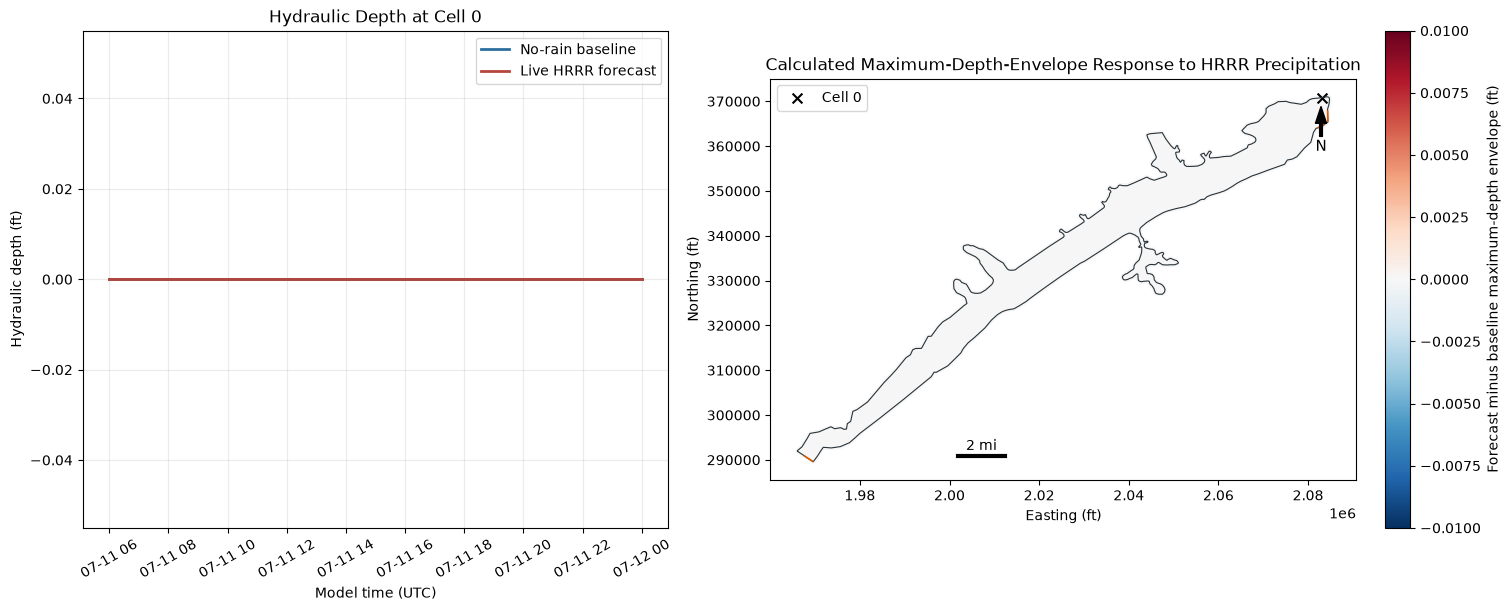

In [11]:
baseline_depth_ts = HdfResultsMesh.get_mesh_timeseries(
    baseline_hdf, MESH_NAME, "Cell Hydraulic Depth", truncate=False
)
forecast_depth_ts = HdfResultsMesh.get_mesh_timeseries(
    forecast_hdf, MESH_NAME, "Cell Hydraulic Depth", truncate=False
)
baseline_depth_values = np.asarray(baseline_depth_ts.values, dtype=float)
forecast_depth_values = np.asarray(forecast_depth_ts.values, dtype=float)
if baseline_depth_values.shape != forecast_depth_values.shape:
    raise RuntimeError("Baseline and forecast depth arrays have different shapes")

baseline_depth_values[baseline_depth_values < 0] = np.nan
forecast_depth_values[forecast_depth_values < 0] = np.nan
with warnings.catch_warnings():
    warnings.filterwarnings("ignore", message="All-NaN slice encountered", category=RuntimeWarning)
    baseline_depth_max = np.nanmax(baseline_depth_values, axis=0)
    forecast_depth_max = np.nanmax(forecast_depth_values, axis=0)

mesh_cell_points = HdfMesh.get_mesh_cell_points(baseline_hdf)
mesh_cell_points = mesh_cell_points.loc[
    mesh_cell_points["mesh_name"] == MESH_NAME,
    ["mesh_name", "cell_id", "geometry"],
].sort_values("cell_id").reset_index(drop=True)
if len(mesh_cell_points) != baseline_depth_values.shape[1]:
    raise RuntimeError(
        f"Cell geometry count {len(mesh_cell_points)} does not match depth columns "
        f"{baseline_depth_values.shape[1]}"
    )

depth_comparison = mesh_cell_points.copy()
depth_comparison["baseline_max_depth_ft"] = baseline_depth_max
depth_comparison["forecast_max_depth_ft"] = forecast_depth_max
depth_comparison["maximum_depth_envelope_change_ft"] = (
    depth_comparison["forecast_max_depth_ft"] - depth_comparison["baseline_max_depth_ft"]
)

baseline_wse_ts = HdfResultsMesh.get_mesh_timeseries(
    baseline_hdf, MESH_NAME, "Water Surface", truncate=False
)
forecast_wse_ts = HdfResultsMesh.get_mesh_timeseries(
    forecast_hdf, MESH_NAME, "Water Surface", truncate=False
)
baseline_wse_values = np.asarray(baseline_wse_ts.values, dtype=float)
forecast_wse_values = np.asarray(forecast_wse_ts.values, dtype=float)
if baseline_wse_values.shape != forecast_wse_values.shape:
    raise RuntimeError("Baseline and forecast water-surface arrays have different shapes")
baseline_wse_values[baseline_wse_values < -1e20] = np.nan
forecast_wse_values[forecast_wse_values < -1e20] = np.nan

depth_delta = depth_comparison["maximum_depth_envelope_change_ft"].replace(
    [np.inf, -np.inf], np.nan
)
wet_threshold_ft = 0.1
baseline_ever_wet = baseline_depth_max > wet_threshold_ft
forecast_ever_wet = forecast_depth_max > wet_threshold_ft
wet_in_both_at_timestep = (
    (baseline_depth_values > wet_threshold_ft)
    & (forecast_depth_values > wet_threshold_ft)
)
concurrent_wse_delta = np.where(
    wet_in_both_at_timestep,
    forecast_wse_values - baseline_wse_values,
    np.nan,
)
finite_concurrent_wse_delta = concurrent_wse_delta[np.isfinite(concurrent_wse_delta)]
if not finite_concurrent_wse_delta.size:
    raise RuntimeError("No concurrent wet-in-both WSE comparisons are available")

hydraulic_summary = pd.DataFrame(
    [
        {
            "baseline_ever_wet_cells_gt_0.1_ft": int(np.count_nonzero(baseline_ever_wet)),
            "forecast_ever_wet_cells_gt_0.1_ft": int(np.count_nonzero(forecast_ever_wet)),
            "newly_wet_cells": int(np.count_nonzero(forecast_ever_wet & ~baseline_ever_wet)),
            "persistently_wet_cells": int(np.count_nonzero(forecast_ever_wet & baseline_ever_wet)),
            "lost_wetting_cells": int(np.count_nonzero(~forecast_ever_wet & baseline_ever_wet)),
            "maximum_depth_envelope_increase_ft": float(depth_delta.max()),
            "minimum_depth_envelope_change_ft": float(depth_delta.min()),
            "maximum_concurrent_wet_in_both_wse_increase_ft": float(
                finite_concurrent_wse_delta.max()
            ),
            "minimum_concurrent_wet_in_both_wse_change_ft": float(
                finite_concurrent_wse_delta.min()
            ),
            "cells_depth_envelope_increase_gt_0.1_ft": int(np.count_nonzero(depth_delta > 0.1)),
            "cells_depth_envelope_decrease_lt_minus_0.1_ft": int(np.count_nonzero(depth_delta < -0.1)),
        }
    ]
)
display(hydraulic_summary.round(4).T.rename(columns={0: "value"}))

representative_row = depth_comparison.loc[depth_delta.idxmax()]
representative_cell = int(representative_row["cell_id"])
baseline_times = pd.DatetimeIndex(pd.to_datetime(baseline_depth_ts.coords["time"].values))
forecast_times = pd.DatetimeIndex(pd.to_datetime(forecast_depth_ts.coords["time"].values))

fig, (ax_ts, ax_delta) = plt.subplots(1, 2, figsize=(15, 6), constrained_layout=True)
ax_ts.plot(
    baseline_times,
    np.asarray(baseline_depth_ts.values[:, representative_cell], dtype=float),
    color="#2b6f9f",
    linewidth=2,
    label="No-rain baseline",
)
ax_ts.plot(
    forecast_times,
    np.asarray(forecast_depth_ts.values[:, representative_cell], dtype=float),
    color="#b5453c",
    linewidth=2,
    label="Live HRRR forecast",
)
ax_ts.set(
    title=f"Hydraulic Depth at Cell {representative_cell}",
    xlabel="Model time (UTC)",
    ylabel="Hydraulic depth (ft)",
)
ax_ts.tick_params(axis="x", rotation=30)
ax_ts.grid(alpha=0.25)
ax_ts.legend()

finite_abs = np.abs(depth_delta.dropna())
color_limit = max(float(finite_abs.max()) if len(finite_abs) else 0.0, 0.01)
depth_comparison.plot(
    ax=ax_delta,
    column="maximum_depth_envelope_change_ft",
    cmap="RdBu_r",
    vmin=-color_limit,
    vmax=color_limit,
    markersize=4,
    legend=True,
    legend_kwds={"label": "Forecast minus baseline maximum-depth envelope (ft)"},
)
mesh_areas.boundary.plot(ax=ax_delta, color="#263238", linewidth=0.8)
if not bc_lines.empty:
    bc_lines.plot(ax=ax_delta, color="#d95f02", linewidth=1.2)
ax_delta.scatter(
    representative_row.geometry.x,
    representative_row.geometry.y,
    color="black",
    marker="x",
    s=50,
    label=f"Cell {representative_cell}",
)
ax_delta.set(
    title="Calculated Maximum-Depth-Envelope Response to HRRR Precipitation",
    xlabel="Easting (ft)",
    ylabel="Northing (ft)",
)
ax_delta.set_aspect("equal")
ax_delta.legend(loc="best")
ax_delta.annotate(
    "N",
    xy=(0.94, 0.93),
    xytext=(0.94, 0.82),
    xycoords="axes fraction",
    arrowprops=dict(facecolor="black", width=2, headwidth=8),
    ha="center",
    fontsize=11,
)
delta_xmin, delta_xmax = ax_delta.get_xlim()
delta_ymin, delta_ymax = ax_delta.get_ylim()
delta_scale_x = delta_xmin + 0.32 * (delta_xmax - delta_xmin)
delta_scale_y = delta_ymin + 0.06 * (delta_ymax - delta_ymin)
ax_delta.plot(
    [delta_scale_x, delta_scale_x + scale_ft],
    [delta_scale_y, delta_scale_y],
    color="black",
    linewidth=3,
)
ax_delta.text(
    delta_scale_x + scale_ft / 2,
    delta_scale_y + 0.015 * (delta_ymax - delta_ymin),
    "2 mi",
    ha="center",
)
plt.show()

## Engineering Interpretation and Constraints

This notebook demonstrates an end-to-end forecast-forcing evaluation:

- One HRRR cycle is examined through two distinct NOAA products: source-timed `wrfsubhf` records for the timing API and hourly `wrfsfc` APCP grids for DSS forcing. They share a cycle and period but are not a record-for-record transformation.
- HEC-RAS 7.0 executes both a no-rain baseline and live HRRR plan.
- Result HDF files prove whether precipitation was consumed and quantify the calculated hydraulic response.
- The extracted project and result HDF files remain under `working/` for GUI review.

The following constraints control interpretation:

1. **Precipitation is the only live forecast input.** The upstream hydrograph is synthetic and is held identical between plans.
2. **Gate operations are assumed.** Sayers Dam Gate #1 remains at the supplied 2.0-foot opening because observed or forecast operating data are unavailable.
3. **The model is instructional.** Its coarse mesh and diffusion-wave formulation are not a calibrated operational-forecast model.
4. **A dry cycle is valid.** A live HRRR forecast can produce little or no hydraulic difference.
5. **The analysis polygon is not a watershed delineation.** It demonstrates the basin-average API contract; production work should use the engineering watershed.
6. **Results require professional review.** The algorithm surfaces calculated spatial and temporal response; it does not establish forecast accuracy, risk, benefit, or adverse impact.

In [12]:
print("=" * 76)
print("END-TO-END HRRR / HEC-RAS EXECUTION AND HYDRAULIC AUDIT COMPLETE")
print("=" * 76)
print(f"Forecast cycle: {selected_cycle:%Y-%m-%d %H}Z")
print(f"HEC-RAS version: {RAS_VERSION}")
print(f"Baseline plan: p{baseline_plan} - SUCCESS")
print(f"HRRR forecast plan: p{forecast_plan} - SUCCESS")
print(f"DSS grids consumed: {len(dss_audit)}")
print(
    "Maximum depth-envelope increase: "
    f"{hydraulic_summary.iloc[0]['maximum_depth_envelope_increase_ft']:.4f} ft"
)
print(f"Model project retained at: {ras.project_folder}")

# The full-CONUS and qpkit GRIB files are large and no longer needed after the
# forcing and hydraulic checks. Retain the portable DSS file and HEC-RAS model.
for transient_dir in (subhourly_grib_dir, qpkit_grib_dir):
    resolved = transient_dir.resolve()
    if not resolved.is_relative_to((repo_root / "working").resolve()):
        raise RuntimeError(f"Refusing to clean unexpected path: {resolved}")
    if resolved.exists():
        shutil.rmtree(resolved)
print("Removed transient GRIB2 downloads; retained DSS, plans, and result HDF files.")

END-TO-END HRRR / HEC-RAS EXECUTION AND HYDRAULIC AUDIT COMPLETE
Forecast cycle: 2026-07-11 06Z
HEC-RAS version: 7.0
Baseline plan: p07 - SUCCESS
HRRR forecast plan: p08 - SUCCESS
DSS grids consumed: 18
Maximum depth-envelope increase: 0.0000 ft
Model project retained at: C:\Users\bill\.config\superpowers\worktrees\ras-commander\codex-hrrr-basin-time\working\example_916_hrrr_ras\20260712T032014Z\model\BaldEagleCrkMulti2D_hrrr_forecast


Removed transient GRIB2 downloads; retained DSS, plans, and result HDF files.
